# <u>**Progress Report 11/2024**</u>

## **1. Data Parsing and Extraction**

### **Program**: <span style="color:green;">**sqlite_dicom2.py**</span>

- **Input**: Data Directory containing patient info
- **Output**: an Sqlite3 database containing selected structures 
(currently by default sag images of the bladder midline and one layer to the left and right, 3 layers removed)

**Usage notes**: 
1. One file per patient, with all sequences in the zip file
2. Place all the zip files in a single directory
3. Launch sqlite_dicom2.py and select the director containing the zip files
4. Enter a name for the sqlite database. It will be stored in the data directory.

**To Do Improvements/Modifications**:
- Add ability to select the structure to be studied (bladder/Rectum/Prostate etc)
- Add ability to select which layers to use for image/mask saving (Midline +/- how many layers)
- Add ability to add structure masks to existing database (must use same images and layers)
- This would require saving the layer number and orientation for each saved image

___

## **2. Database Viewing and Modification**

### **Program**: <span style="color:yellow;">sqlite_viewer.py</span>

The database can be viewed and modified.
**Keys**: 
- m : show mask on/off
- d : delete current image and mask from database 
- arrow keys : move through the images

## **Demo**

***

### <span style="color:red;">**Problems**</span>

- sometimes the bladder incompletely captured / cut off, the scanned region varies widely from study to study
- presents a issue for training the model, requires more data than would be necessary if the cone beams were more standardized
- sometimes there are 88 slices, sometimes only 85. Images must be of equal dimensions for training algorithm

### <span style="color:green;">**Suggestions**</span>

- Standardize the cone beam acquisition protocol by region and dimension, e.g. by location of symphysis pubis

### To Do
- add ability to go to patient
- show number of images per patient, also show slice number

___

In [4]:
# import the required modules
from sqlitedata import SqliteData
from sklearnex import patch_sklearn
patch_sklearn()


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


## **3. Load the Data**

- Use the sqlite database constructed during the parsing & extraction via the sqlite_dicom2 tool of the DICOM files 

In [6]:
# set the database file
# dbfile = '/media/peter/data/md_data/processed/imagesV5.sqlite'
dbfile = '/media/peter/videodump/md_data/imagesV5.sqlite'

# open the database
db = SqliteData(dbfile)

In [7]:
# get the image data
images,masks = db.get_images_and_masks('bladder')

# close the database
db.close()

OperationalError: no such column: cbct_mask

### View Information about the Database size

And visualize a sample entry

In [152]:
print(f'Number of images: {len(images)}, Number of masks: {len(masks)}')

Number of images: 2139, Number of masks: 2139


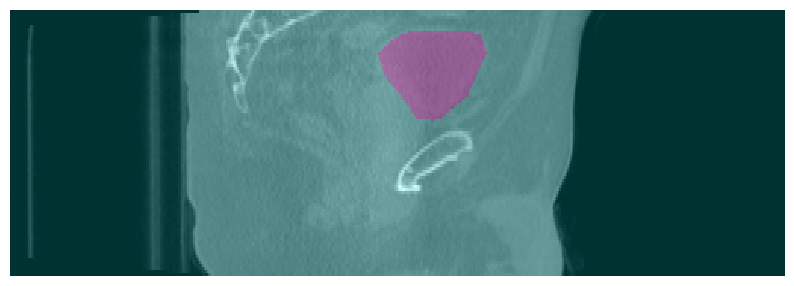

In [153]:
# display a random image with mask overlayed in transparent blue using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# set the image and mask number by choosing a random index
idx = numpy.random.randint(0,len(images))
image = images[idx]
mask = masks[idx]

# create a figure
fig, ax = plt.subplots(1,1,figsize=(10,10))

# modify the y axis tics to only show every 10th tic

sns.heatmap(image, ax=ax, cmap='gray', cbar=False) # hide the colorbar
sns.heatmap(mask, ax=ax, cmap='cool', alpha=0.2, cbar=False)

# hide the axis
ax.axis('off')

#scale the y axis by 0.5
ax.set_aspect(2)

plt.show()

## **4. Data Preprocessing**

1. Analyse the imported images to eliminate problem files (wrong image dimensions)

In [154]:
# first check that all image dimensions are the same
shapes = []
for img in images:
    # assert img.shape == images[0].shape, 'All images must have the same dimensions'
    shapes.append(img.shape)

shapes_dict = dict((x, shapes.count(x)) for x in set(shapes))
print(f"Number of images of each size: ")
for entry in shapes_dict:
    print(f"{entry}: {shapes_dict[entry]}")

Number of images of each size: 
(85, 512): 12
(88, 512): 2127


### Remove images  of size 85, 512

In [155]:
# remove images with dimension (85,512) and the corresponding masks
images = [img for img in images if img.shape != (85,512)]
masks = [mask for mask in masks if mask.shape != (85,512)]


### Normalization

- Covert the image data to floating point
- covert the mask to binary

In [156]:

images = [img.astype('float32') for img in images]
masks = [mask.astype('bool') for mask in masks]

In [157]:
print(f"Range of pixel values: {numpy.min(images)}, {numpy.max(images)}")
print(f"Mask arrays are dim: {masks[0].shape} and of dtype {masks[0].dtype}")

Range of pixel values: 0.0, 8000.0
Mask arrays are dim: (88, 512) and of dtype bool


 - Divide all the pixel values by the maximum to get the images onto the
0-1 scale required for AI training

In [158]:
images = [img/numpy.max(img) for img in images]
print(f"After scaling, range of pixel values: {numpy.min(images)}, {numpy.max(images)}")

After scaling, range of pixel values: 0.0, 1.0


### View results

Redisplay an image after scaling to ensure no loss of image quality

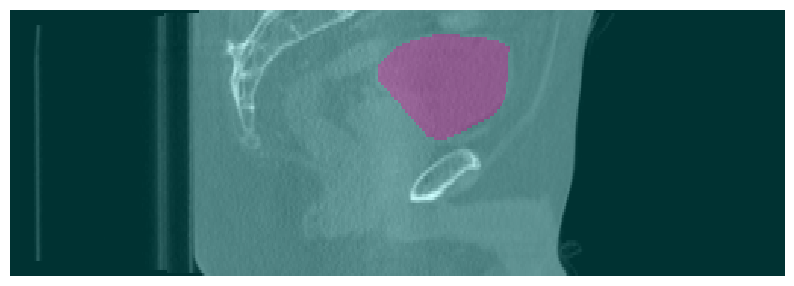

In [159]:
image = images[idx]
mask = masks[idx]

# create a figure
fig, ax = plt.subplots(1,1,figsize=(10,10))

sns.heatmap(image, ax=ax, cmap='gray', cbar=False) # hide the colorbar
sns.heatmap(mask, ax=ax, cmap='cool', alpha=0.2, cbar=False)
#scale the y axis by 0.5
ax.set_aspect(2)
ax.axis('off')

plt.show()

## **5. AI Model Training**

- First split the data into training and validation groups

In [71]:
# separate the image and mask data into training and validation sets
from sklearn.model_selection import train_test_split

# split the data into training and validation sets
train_images, val_images, train_masks, val_masks = train_test_split(images, masks, test_size=0.2)

print(f'Training images: {len(train_images)}, Validation images: {len(val_images)}')

Training images: 1701, Validation images: 426


In [ ]:
from sklearn.metrics import accuracy_score

X_train = train_images 
y_train = train_masks 

# Flatten the validation images and masks for testing
X_val = val_images 
y_val = val_masks 

## The AI Training algorithm

### Loss functions tested

 - **BCELoss** - poor results - discarded
 - **Combined Loss** = BCELoss + DiceLoss - much better for segmentation tasks, but finds many artifacts surrounding bladder. <span style="color:yellow;">modelV2.pth</span>
 - **ConnectedComponentLoss** <span style="color:lime;">modelV3.pth</span>
 - **ConnectedComponentLoss with Combined Loss = <span style="color:orange;">modelV4.pth</span> crashes the kernel
 - on GPU using U-Net model with loss function encorporating BCE / Dice and Connected Component Loss produces best results

 Some optimization needed. Will test more variations on GPU to optimize predection results



In [ ]:
# scikit-learn was a flop.
# Let's try a different approach using a neural network, with pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Define Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        # Flatten inputs and targets
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        # Calculate intersection
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice

def combined_loss(inputs, targets):
    bce = nn.BCELoss()(inputs, targets)
    dice = DiceLoss()(inputs, targets)
    return bce + dice


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # Input size preservation with proper padding
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2, padding=1)
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        # Decoder with matching dimensions
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        up1 = self.upconv1(e2)

        # Match dimensions for concatenation
        if up1.shape != e1.shape:
            up1 = nn.functional.pad(up1, [0, e1.shape[3] - up1.shape[3], 
                                        0, e1.shape[2] - up1.shape[2]])
        
        d1 = torch.cat([up1, e1], dim=1)
        out = self.dec1(d1)
        return out

class ImageDataset(Dataset):
    def __init__(self, images, masks):
        # Add channel dimension and normalize
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1) #/ 255.0
        self.masks = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

# Initialize model
model = Net()
# Adjust Hyperparameters
learning_rate = 1e-4
num_epochs = 25
batch_size = 4
# Initialize model and optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = combined_loss

# Create data loaders
train_dataset = ImageDataset(train_images, train_masks)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# Training loop
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (images, masks) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        if batch_idx % 10 == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}')

Epoch: 0, Batch: 0, Loss: 1.4361
Epoch: 0, Batch: 10, Loss: 1.4064
Epoch: 0, Batch: 20, Loss: 1.3480
Epoch: 0, Batch: 30, Loss: 1.3227
Epoch: 0, Batch: 40, Loss: 1.2884
Epoch: 0, Batch: 50, Loss: 1.2907
Epoch: 0, Batch: 60, Loss: 1.2454
Epoch: 0, Batch: 70, Loss: 1.2234
Epoch: 0, Batch: 80, Loss: 1.1534
Epoch: 0, Batch: 90, Loss: 1.1424
Epoch: 0, Batch: 100, Loss: 1.1449
Epoch: 0, Batch: 110, Loss: 1.1533
Epoch: 0, Batch: 120, Loss: 1.1455
Epoch: 0, Batch: 130, Loss: 1.1087
Epoch: 0, Batch: 140, Loss: 1.1171
Epoch: 0, Batch: 150, Loss: 1.0586
Epoch: 0, Batch: 160, Loss: 1.0765
Epoch: 0, Batch: 170, Loss: 1.0675
Epoch: 0, Batch: 180, Loss: 1.0299
Epoch: 0, Batch: 190, Loss: 0.9842
Epoch: 0, Batch: 200, Loss: 1.0016
Epoch: 0, Batch: 210, Loss: 0.9396
Epoch: 0, Batch: 220, Loss: 0.9585
Epoch: 0, Batch: 230, Loss: 1.0460
Epoch: 0, Batch: 240, Loss: 0.9858
Epoch: 0, Batch: 250, Loss: 0.9418
Epoch: 0, Batch: 260, Loss: 1.0288
Epoch: 0, Batch: 270, Loss: 1.0256
Epoch: 0, Batch: 280, Loss: 0.9

In [ ]:
# Save the model
torch.save(model.state_dict(), 'modelV6.pth')

### Post processing

- To reduce the number of spurious artifacts, post process the predictions to return the largest connected region
    - only possible on GPU
- Finally check the accuracy of the predictions by comparing to the known masks derived from the contours

In [147]:
# Convert validation images to PyTorch tensors
# Ensure images are float tensors and add channel dimension if necessary
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)  # Shape: (batch_size, 1, H, W)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)  # Shape: (batch_size, 1, H, W)

# Set model to evaluation mode
model.eval()

with torch.no_grad():
    # Predict the masks for the validation images
    y_pred = model(X_val_tensor)

# Since y_pred is a tensor, convert it to NumPy array
y_pred = y_pred.numpy()

# Binarize the predictions (assuming output is between 0 and 1)
y_pred_binary = (y_pred > 0.5).astype(np.uint8)

# Flatten the predictions and true masks
y_pred_flat = y_pred_binary.flatten()
y_val_flat = y_val_tensor.numpy().flatten().astype(np.uint8)

# Calculate the accuracy
accuracy = accuracy_score(y_val_flat, y_pred_flat)
print(f'Validation Accuracy: {accuracy*100:.2f}%')

Validation Accuracy: 95.74%


In [1]:
# Display the results
fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# Choose a random patient
rnd_pat = np.random.randint(len(X_val))

# sns.heatmap(X_val[rnd_pat], ax=ax[0], cmap='gray', cbar=False)
ax[0].imshow(X_val[rnd_pat], cmap='gray')
ax[0].set_title('Image')
ax[0].axis('off')


sns.heatmap(y_val[rnd_pat], ax=ax[1], cmap='hot', cbar=False)
ax[1].set_title('True Mask')
ax[1].axis('off')

# sns.heatmap(y_pred[0, 0], ax=ax[2], cmap='cool', cbar=False)
#predicted mask:
sns.heatmap(y_pred[rnd_pat, 0], ax=ax[2], cmap='hot', cbar=False)
ax[2].set_title('Predicted Mask')
ax[2].axis('off')

for a in ax:
    a.set_aspect(2)

plt.show()

NameError: name 'plt' is not defined

## **6. Conclusions**

- Basic Neural Net running on CPU produces impressive results
- Many options to improve prediction quality
    1. Better acquisition parameters:
        - stardardized CBCT dimensions and ROI
    2. Training algorithm improvements on GPU with more Epochs, tweaked loss function and hyperparameters
- Define function for calculating estimate of bladder fill
- Repeat procedures for rectum and perhaps other stuctures


To Do 
- compare areas of planungs-CT area and calculated area / bladder 1/2, 2/3, 